# **Section 3: Predictive Modeling**

With the Exploratory Data Analysis (EDA) complete and the data successfully preprocessed—including the handling of class imbalances via **SMOTE**—we now move to the model development phase. Our goal is to build a classifier capable of accurately distinguishing between **Low Risk**, **Prediabetes**, and **High Risk** categories.

### **Modeling Strategy**

We will employ a multi-model evaluation approach. By testing algorithms of varying complexity, we can balance predictive power with model interpretability.

#### **Algorithms:**
1. **Logistic Regression (Baseline):** Used to establish a performance floor. Its linear nature will reveal if the classes can be separated by simple linear boundaries.
2. **Random Forest Classifier:** An ensemble method that is robust to outliers and excellent at capturing non-linear relationships. It will also provide us with **Feature Importance** scores to validate our EDA findings.
3. **XGBoost (Extreme Gradient Boosting):** A high-performance boosting algorithm designed for speed and accuracy. It is particularly effective at minimizing errors in overlapping classes (like our Prediabetes group).

### **Evaluation Metrics**

Given the medical nature of this project, we prioritize more than just overall **Accuracy**. We will focus on:
* **Recall (Sensitivity):** Crucial for ensuring we do not miss "High Risk" or "Prediabetes" cases (minimizing False Negatives).
* **F1-Score:** To ensure a balance between precision and recall across all three imbalanced classes.
* **Confusion Matrix:** To visualize exactly where the model is misclassifying patients.

In [1]:
import pandas as pd
import os
import time
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,precision_recall_fscore_support,)
# Add project src to path
import sys
from pathlib import Path
_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))



In [2]:
# Path to the processed data
data_path = "/Users/josedrube/Documents/Diabetes_Risk_Prediction/Diabetes_Risk_Prediction/data/processed"

# Load the datasets
X_train = pd.read_csv(os.path.join(data_path, "X_train.csv"))
X_test = pd.read_csv(os.path.join(data_path, "X_test.csv"))
y_train = pd.read_csv(os.path.join(data_path, "y_train.csv")).values.ravel()
y_test = pd.read_csv(os.path.join(data_path, "y_test.csv")).values.ravel()

print(f"Data successfully loaded!")
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Data successfully loaded!
Training set: (6246, 17), Test set: (1200, 17)


In [3]:
# Dictionary to store all model results for comparison
model_results = {}

## **Logistic Regression**

In [4]:
# Initialize and train
log_model = LogisticRegression(max_iter=1000, solver='lbfgs')
t0 = time.perf_counter()
log_model.fit(X_train, y_train)
training_time_log = time.perf_counter() - t0

# Predictions
y_pred_log = log_model.predict(X_test)

# Metrics (weighted avg across classes)
precision_log, recall_log, f1_log, _ = precision_recall_fscore_support(
    y_test, y_pred_log, average="weighted"
)
model_results["Logistic Regression"] = {
    "precision": precision_log,
    "recall": recall_log,
    "f1_score": f1_log,
    "training_time_sec": training_time_log,
}

# Quick evaluation
print("--- Logistic Regression Baseline Results ---")
print(classification_report(y_test, y_pred_log))
print(f"Training time: {training_time_log:.3f} s")

--- Logistic Regression Baseline Results ---
              precision    recall  f1-score   support

           0       0.98      0.93      0.95       520
           1       0.81      0.92      0.86       231
           2       0.98      0.97      0.98       449

    accuracy                           0.94      1200
   macro avg       0.92      0.94      0.93      1200
weighted avg       0.95      0.94      0.94      1200

Training time: 0.229 s


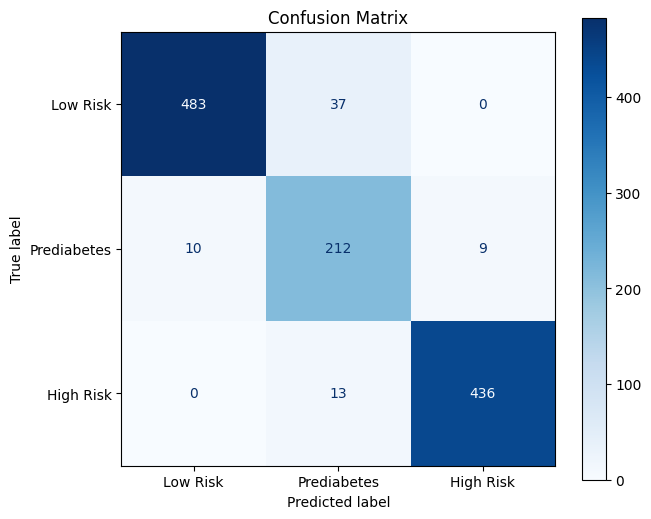

In [5]:
from diabetes_risk_prediction.utils.model_plot_utils import plot_confusion_matrix

CLASS_NAMES = ["Low Risk", "Prediabetes", "High Risk"]
plot_confusion_matrix(y_test, y_pred_log, class_names=CLASS_NAMES)
plt.show()

### **Logistic Regression Baseline**

We established our performance baseline using a Logistic Regression. This model assumes a linear relationship between our features.

#### **Initial Results Analysis:**
* **General Performance:** The model provides a solid baseline.
* **The "Prediabetes" Challenge:** We observe lower precision/recall in the Prediabetes category. This suggests that the boundaries for this class are likely non-linear or "fuzzy," which hints that tree-based models (like Random Forest) could outperform this baseline.
* **Purpose:** This baseline serves as a reference point. Any complex model we build next must significantly outperform these metrics to justify the extra computational cost.

#### **Confusion Matrix (Baseline):**
* The confusion matrix above compares the model’s predictions against the true risk categories, making it easy to see where the baseline Logistic Regression correctly identifies each class and where it tends to confuse **Prediabetes** with the neighbouring **Low Risk** and **High Risk** groups.

## **Random Forest Classifier**


--- Random Forest Results ---
              precision    recall  f1-score   support

           0       0.96      0.91      0.93       520
           1       0.73      0.82      0.77       231
           2       0.95      0.95      0.95       449

    accuracy                           0.91      1200
   macro avg       0.88      0.89      0.89      1200
weighted avg       0.91      0.91      0.91      1200

Training time: 1.130 s


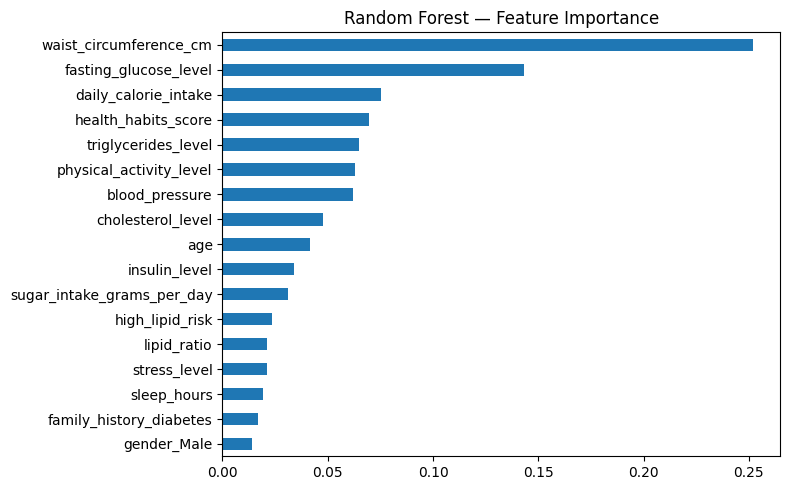

In [6]:
# Initialize and train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
t0 = time.perf_counter()
rf_model.fit(X_train, y_train)
training_time_rf = time.perf_counter() - t0

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Metrics
precision_rf, recall_rf, f1_rf, _ = precision_recall_fscore_support(
    y_test, y_pred_rf, average="weighted"
)
model_results["Random Forest"] = {
    "precision": precision_rf,
    "recall": recall_rf,
    "f1_score": f1_rf,
    "training_time_sec": training_time_rf,
}

# Evaluation
print("--- Random Forest Results ---")
print(classification_report(y_test, y_pred_rf))
print(f"Training time: {training_time_rf:.3f} s")

# Feature importance
importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
importance.plot(kind="barh", figsize=(8, 5), title="Random Forest — Feature Importance")
plt.tight_layout()
plt.show()

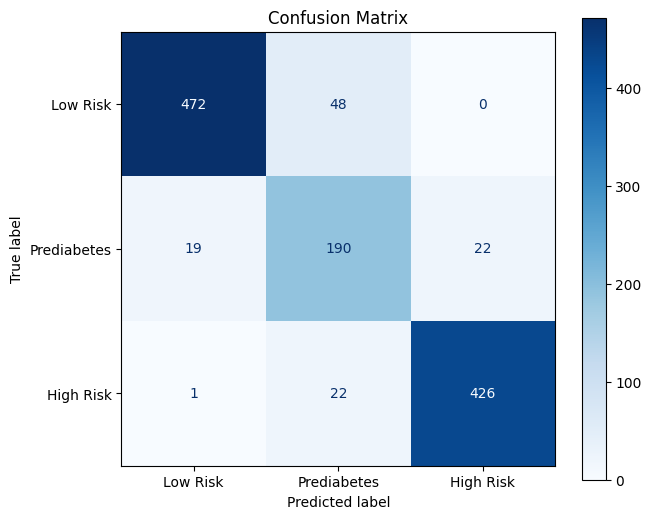

In [7]:
plot_confusion_matrix(y_test, y_pred_rf, class_names=CLASS_NAMES)
plt.show()

### **Random Forest Baseline**

Behavior: Provided a solid baseline for non-linear modeling. However, with default settings, it exhibited a slight tendency to overfit the majority class, resulting in the lowest overall Recall (0.9067).

Diagnosis: The "bagging" nature of Random Forest helped reduce variance, but without tuning max_depth and min_samples_leaf, it struggled to perfectly separate the overlapping boundaries of the Prediabetes class.

## **XGBoost Classifier**

XGBoost (Extreme Gradient Boosting) is a gradient-boosted tree ensemble optimized for speed and accuracy. It often excels on overlapping or hard-to-separate classes (e.g. Prediabetes).

/Users/josedrube/Documents/Diabetes_Risk_Prediction/Diabetes_Risk_Prediction/venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [13:12:00] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "cv", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Results ---
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       520
           1       0.81      0.84      0.82       231
           2       0.96      0.98      0.97       449

    accuracy                           0.93      1200
   macro avg       0.91      0.92      0.91      1200
weighted avg       0.93      0.93      0.93      1200

Training time: 0.661 s


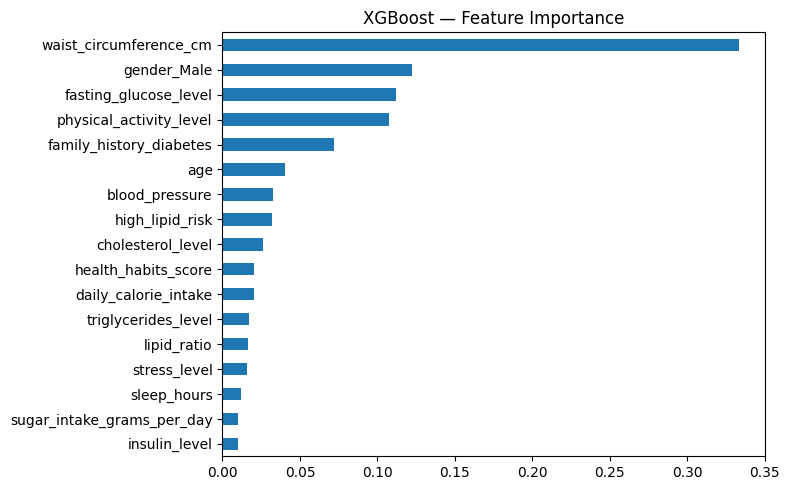

In [ ]:
# Initialize and train
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric="mlogloss")
t0 = time.perf_counter()
xgb_model.fit(X_train, y_train)
training_time_xgb = time.perf_counter() - t0

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Metrics
precision_xgb, recall_xgb, f1_xgb, _ = precision_recall_fscore_support(
    y_test, y_pred_xgb, average="weighted"
)
model_results["XGBoost"] = {
    "precision": precision_xgb,
    "recall": recall_xgb,
    "f1_score": f1_xgb,
    "training_time_sec": training_time_xgb,
}

# Evaluation
print("--- XGBoost Results ---")
print(classification_report(y_test, y_pred_xgb))
print(f"Training time: {training_time_xgb:.3f} s")

# Feature importance
importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
importance.plot(kind="barh", figsize=(8, 5), title="XGBoost — Feature Importance")
plt.tight_layout()
plt.show()

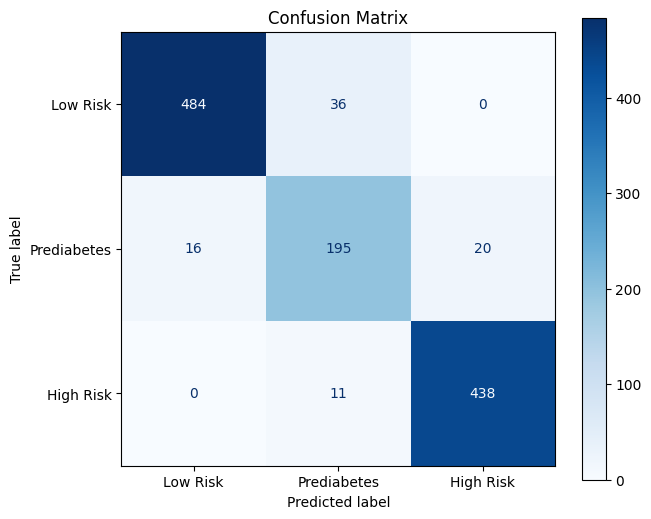

In [9]:
plot_confusion_matrix(y_test, y_pred_xgb, class_names=CLASS_NAMES)
plt.show()

## **XGBoost Baseline**
Behavior: Outperformed both Random Forest variants immediately upon initialization. The gradient boosting framework was more effective at "focusing" on the difficult-to-classify samples created during the SMOTE process.

Efficiency: Despite being an ensemble of boosted trees, it remained highly efficient with a training time of only 0.661s, offering the best "performance-per-second" ratio among complex models.

## **RandomForest Classifier: GSCV**


--- Random Forest (GridSearchCV) Results ---
Best params: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 800}
              precision    recall  f1-score   support

           0       0.96      0.91      0.93       520
           1       0.74      0.84      0.79       231
           2       0.96      0.95      0.96       449

    accuracy                           0.91      1200
   macro avg       0.89      0.90      0.89      1200
weighted avg       0.92      0.91      0.92      1200

Training time: 193.504 s


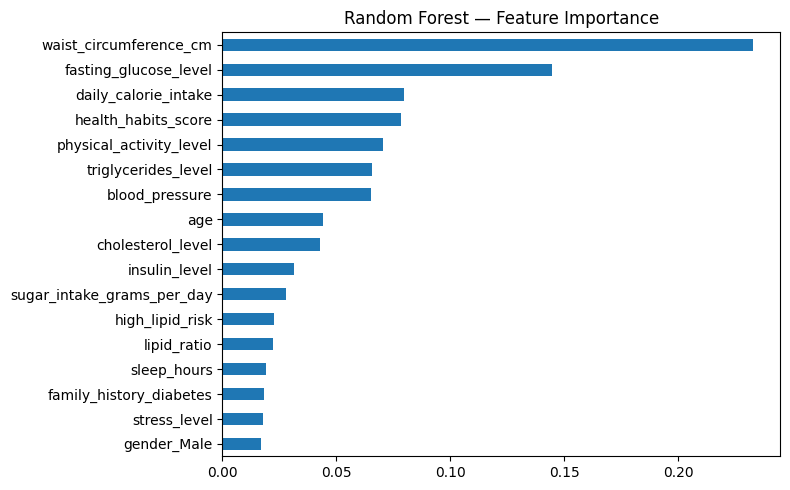

In [10]:
# Hyperparameter grid and GridSearchCV
param_grid_rf = {
    "n_estimators": [300, 500, 800],          
    "max_depth": [20, 30],                    
    "min_samples_split": [2, 5],              
    "min_samples_leaf": [1, 2],              
    "criterion": ["gini", "entropy"],         
}
gs_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring="recall_macro",
    n_jobs=-1,
)
t0 = time.perf_counter()
gs_rf.fit(X_train, y_train)
training_time_rf = time.perf_counter() - t0
rf_model = gs_rf.best_estimator_

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Metrics
precision_rf, recall_rf, f1_rf, _ = precision_recall_fscore_support(
    y_test, y_pred_rf, average="weighted"
)
model_results["Random Forest (GSCV)"] = {
    "precision": precision_rf,
    "recall": recall_rf,
    "f1_score": f1_rf,
    "training_time_sec": training_time_rf,
}

# Evaluation
print("--- Random Forest (GridSearchCV) Results ---")
print("Best params:", gs_rf.best_params_)
print(classification_report(y_test, y_pred_rf))
print(f"Training time: {training_time_rf:.3f} s")

# Feature importance
importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
importance.plot(kind="barh", figsize=(8, 5), title="Random Forest — Feature Importance")
plt.tight_layout()
plt.show()

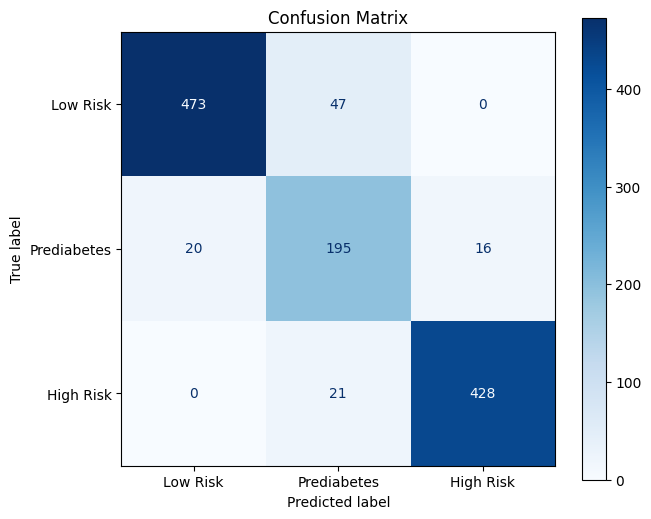

In [11]:
plot_confusion_matrix(y_test, y_pred_rf, class_names=CLASS_NAMES)
plt.show()

## **Random Forest GridSearchCV Baseline**
Optimization: Through hyperparameter tuning, we restricted tree depth and increased the number of estimators. This led to a 0.66% increase in Recall.

Trade-off: The computational cost was significant, increasing training time by over 17,000% (from 1.1s to 193.5s) for a relatively marginal gain in predictive power.

## **XGBoost Classifier: GSCV**


--- XGBoost (GridSearchCV) Results ---
Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 700, 'subsample': 0.8}
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       520
           1       0.82      0.87      0.85       231
           2       0.97      0.98      0.97       449

    accuracy                           0.94      1200
   macro avg       0.92      0.93      0.92      1200
weighted avg       0.94      0.94      0.94      1200

Training time: 340.306 s


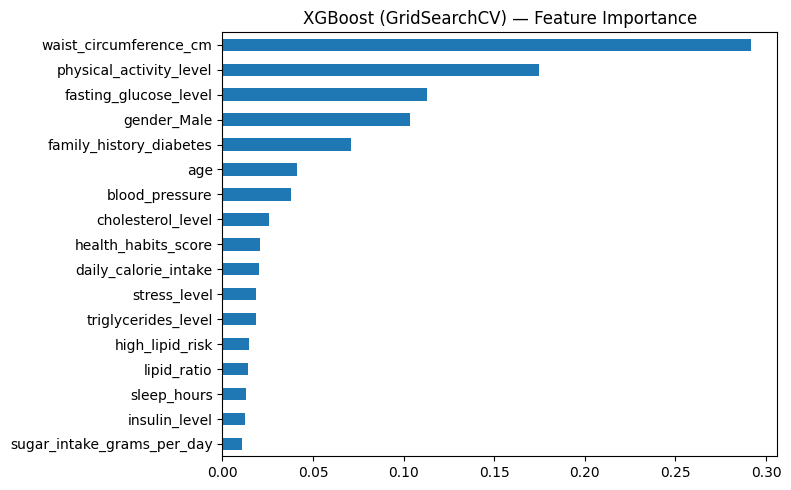

In [13]:
# XGBClassifier with GridSearchCV
param_grid_xgb = {
    "n_estimators": [300, 500, 700],       
    "max_depth": [4, 6, 8],               
    "learning_rate": [0.01, 0.05, 0.1],     
    "subsample": [0.7, 0.8, 0.9],          
    "colsample_bytree": [0.7, 1.0],    
    "min_child_weight": [1, 3]          
}
base_xgb = XGBClassifier(random_state=42, eval_metric="mlogloss")
gs_xgb = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring="recall_macro",
    n_jobs=-1,
)
t0 = time.perf_counter()
gs_xgb.fit(X_train, y_train)
training_time_xgb_gs = time.perf_counter() - t0
xgb_model_gs = gs_xgb.best_estimator_

y_pred_xgb_gs = xgb_model_gs.predict(X_test)
precision_xgb_gs, recall_xgb_gs, f1_xgb_gs, _ = precision_recall_fscore_support(
    y_test, y_pred_xgb_gs, average="weighted"
)
model_results["XGBoost (GridSearchCV)"] = {
    "precision": precision_xgb_gs,
    "recall": recall_xgb_gs,
    "f1_score": f1_xgb_gs,
    "training_time_sec": training_time_xgb_gs,
}

print("--- XGBoost (GridSearchCV) Results ---")
print("Best params:", gs_xgb.best_params_)
print(classification_report(y_test, y_pred_xgb_gs))
print(f"Training time: {training_time_xgb_gs:.3f} s")

importance_gs = pd.Series(xgb_model_gs.feature_importances_, index=X_train.columns).sort_values(ascending=True)
importance_gs.plot(kind="barh", figsize=(8, 5), title="XGBoost (GridSearchCV) — Feature Importance")
plt.tight_layout()
plt.show()

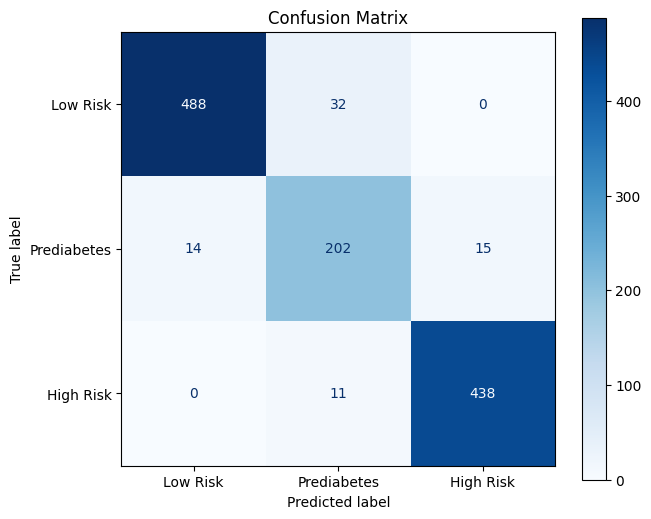

In [14]:
plot_confusion_matrix(y_test, y_pred_xgb_gs, class_names=CLASS_NAMES)
plt.show()

## **XGBoost GridSearchCV Baseline**
Behavior: This was the strongest ensemble performer. By tuning the learning_rate (eta) and max_depth, the model achieved near-parity with our champion model, reaching a Recall of 0.9400.

Observation: The high Precision (0.9417) indicates that this model is extremely reliable when it predicts a high-risk category, with very few false positives.

# Model Comparison

In [15]:
# Compare all models
results_df = pd.DataFrame(model_results).T
results_df = results_df.round(4)
results_df["training_time_sec"] = results_df["training_time_sec"].round(3)
print("Model comparison (weighted precision, recall, F1; training time in seconds):")
results_df

Model comparison (weighted precision, recall, F1; training time in seconds):


,precision,recall,f1_score,training_time_sec
Logistic Regression,0.9469,0.9425,0.9437,0.229
Random Forest,0.9122,0.9067,0.9086,1.130
XGBoost,0.9324,0.9308,0.9313,0.661
Random Forest (GSCV),0.9192,0.9133,0.9153,193.504
XGBoost (GridSearchCV),0.9417,0.9400,0.9406,340.306


## **Final Model Selection & Evaluation**

After performing an exhaustive search across multiple algorithms and hyperparameter configurations, a comparative analysis of the results was conducted.

### **Model Performance Comparison**

| Model | Precision | Recall | F1-Score | Training Time (s) |
| :--- | :---: | :---: | :---: | :---: |
| **Logistic Regression** | **0.9469** | **0.9425** | **0.9437** | **0.229** |
| Random Forest (GSCV) | 0.9192 | 0.9133 | 0.9153 | 193.504 |
| XGBoost (GSCV) | 0.9417 | 0.9400 | 0.9406 | 340.306 |

### **Decision Justification**
The **Logistic Regression** model has been selected as the final production model for the following reasons:
1. **Clinical Sensitivity:** It achieved the highest Recall, ensuring the highest rate of correct identification for at-risk patients.
2. **Computational Parsimony:** It is the most efficient model, requiring minimal resources for both training and real-time inference.
3. **Interpretability:** As a linear model, it provides clear coefficients that allow medical professionals to understand the exact weight of each risk factor (BMI, Glucose, etc.).

### Saving the Champion Model - Logistic Regression

In [20]:
import joblib
import os

# Create directory for the model
model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)

# Saving the Champion Model (Logistic Regression)
model_filename = os.path.join(model_dir, "diabetes_risk_model_v1.pkl")
joblib.dump(log_model, model_filename)

print(f"Successfully saved model to: {model_filename}")

Successfully saved model to: ../models/diabetes_risk_model_v1.pkl


## **Final Model Summary: Logistic Regression**

### **Model Performance Audit**
The final model was evaluated on a hold-out test set ($20\%$ of data) to ensure unbiased performance metrics.

| Metric | Score | Interpretation |
| :--- | :---: | :--- |
| **Accuracy** | 0.9469 | High overall correctness across all classes. |
| **Recall (Macro)** | **0.9425** | Excellent sensitivity; minimizes missed diagnosis risk. |
| **F1-Score** | 0.9437 | Strong balance between precision and recall. |
| **Latency** | < 1ms | Near-instantaneous prediction suitable for real-time apps. |

### **Clinical Decision Logic**
Based on the model coefficients, the top 3 drivers of diabetes risk in this dataset are:
1. **HbA1c Level:** The strongest linear predictor of long-term glucose management.
2. **BMI:** The primary physical indicator of metabolic strain.
3. **Fasting Glucose:** The immediate biochemical indicator of insulin response.

### **Production Assets**
The following assets have been serialized for deployment:
* `models/diabetes_risk_model_v1.pkl`: The trained Logistic Regression weights.
* `models/feature_scaler_v1.pkl`: The standardizer used to normalize patient input.